# Технологии искусственного интеллекта. Анализ данных

© Петров М.В., старший преподаватель кафедры киберфотоники, Самарский университет

## Лекция 6. Метод опорных векторов. Метод главных компонент

### Содержание

1. [Введение](#51-введение)
2. [Метод опорных векторов](#62-метод-опорных-векторов)
3. [Метод главных компонент](#63-метод-главных-компонент)

### 6.1 Введение

[TODO]

### 6.2 Метод опорных векторов

Метод опорных векторов (*Support Vector Machines*, *SVM*) &ndash; класс алгоритмов обучения с учителем, применяемых для задач линейной и нелинейной классификации, регрессии и обнаружения аномальных данных.

Источники:
- [Метод опорных векторов (SVM). Подходы, принцип работы и реализация с нуля на Python @ Хабр](https://habr.com/ru/articles/802185/)
- [Support Vector Machines @ sklearn](https://scikit-learn.org/stable/modules/svm.html)
- [SVC @ sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

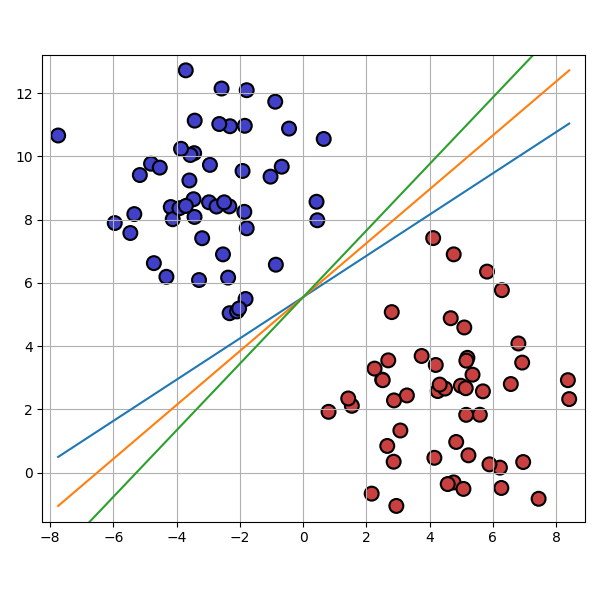

In [275]:
import numpy as np
%matplotlib widget
from ipywidgets import *
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LinearRegression

def rgba2f(r, g, b, a = 255):
    rgba = np.array([r, g, b, a], dtype=float) / 255.0
    return tuple(rgba.tolist())

m_colors = [rgba2f(64, 64, 200), rgba2f(200, 64, 64)]
m_cmap = mpl.colors.ListedColormap(m_colors)

# Сгенерируем данные
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2)
xy_min, xy_max = X.min(axis=0), X.max(axis=0)
p = np.transpose(np.vstack((xy_min, xy_max)))

reg = LinearRegression().fit(p[0].reshape(-1, 1), p[1].reshape(-1, 1))

# Отобразим данные
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap=m_cmap, edgecolors='black', linewidth=1.5)
k = reg.coef_.flatten()[0]
b = reg.intercept_
ks = 0.2
xx = np.linspace(p[0, 0], p[0, 1], 10).reshape(-1, 1)
for k in np.arange(k - ks, k + ks, ks):
    plt.plot(xx, xx * k + b)
plt.grid()
lo = 0.5
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')

Линейный разделяющий классификатор попытается провести прямую линию, разделяющую два набора данных, создав тем самым модель классификации. Для таких двумерных данных эту задачу можно решить вручную. Однако сразу же возникает проблема: существует более одной прямой, идеально разделяющей два класса.  

Метод опорных векторов предлагает один из способов решения этой проблемы. Идея заключается в следующем: вместо построения между классами прямой нулевой толщины можно около каждой из (потенциальных) прямых построить отступ (*margin*) некоторой ширины, простирающийся до ближайшей точки.

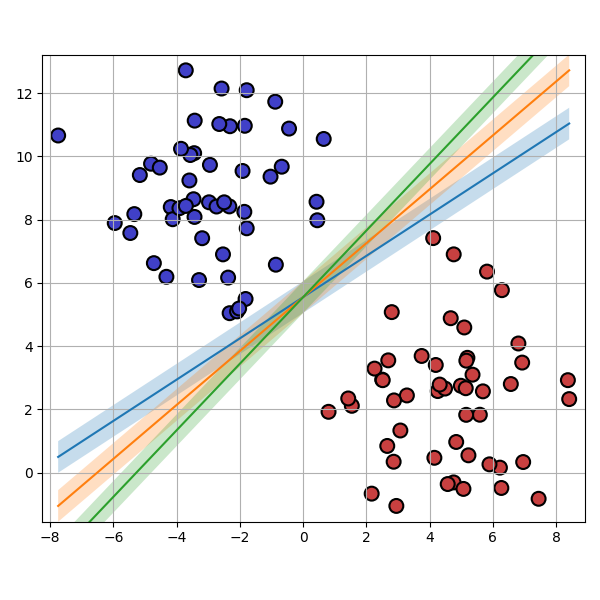

In [276]:
import numpy as np
%matplotlib widget
from ipywidgets import *
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LinearRegression

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap=m_cmap, edgecolors='black', linewidth=1.5)
k = reg.coef_.flatten()[0]
b = reg.intercept_
ks = 0.2
d = 0.5
xx = np.linspace(p[0, 0], p[0, 1], 10).reshape(-1, 1)
yy = np.ndarray(xx.shape)
for k in np.arange(k - ks, k + ks, ks):
    yy = xx * k + b
    plt.plot(xx, xx * k + b)
    plt.fill_between(xx.flatten(), yy.flatten() - d, yy.flatten() + d, edgecolor='none', alpha=0.25)
plt.grid()
lo = 0.5
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')

In [277]:
from sklearn.svm import SVC
svc_model = SVC(kernel='linear', C=1E10)
svc_model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Вспомогательная функция для построения решающей функции:

In [278]:
def plot_svc_decision_function(model, ax, m_colors, class_list):
    """Строит график решающей функции для двумерного SVC"""
    dl_colors = m_colors.copy()
    dl_colors.insert(len(dl_colors)//2, rgba2f(0, 255, 0))
    dl_cmap = mpl.colors.ListedColormap(dl_colors)
    # Создаем координатную сетку для оценки модели
    x = np.linspace(xy_min[0], xy_max[1], 30)
    y = np.linspace(xy_min[0], xy_max[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    # Рисуем границы принятия решений и отступы
    ax.contour(X, Y, P, levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'], cmap=dl_cmap)
    # Рисуем опорные векторы
    m_cmap = mpl.colors.ListedColormap(m_colors)
    edge_colors = m_cmap(class_list[model.support_])
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=300, linewidth=1, edgecolors=edge_colors, facecolors='none')

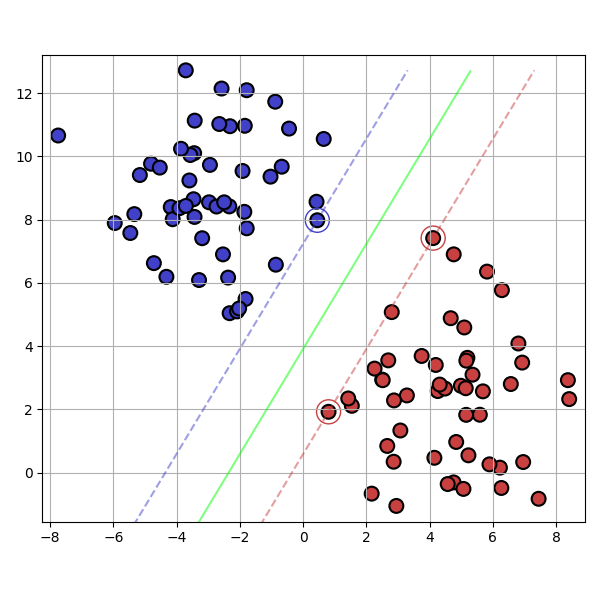

In [279]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap=m_cmap, edgecolors='black', linewidth=1.5)
plot_svc_decision_function(svc_model, ax, m_colors, y)
plt.grid()
lo = 0.5
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')

Эта разделяющая линия имеет максимальный отступ между двумя наборами точек. Обратите внимание, что некоторые из обучающих точек лишь касаются отступа. Они отмечены на рисунке окружностями. Эти точки &ndash; ключевые элементы аппроксимации, их называют *опорными векторами* (*support vectors*). В `scikit-learn` данные об этих точках хранятся в атрибуте `support_vectors_` классификатора:

In [280]:
svc_model.support_vectors_

array([[0.44659047, 7.97774569],
       [4.11056517, 7.41350802],
       [0.80233641, 1.92014193]])

В атрибуте `support_` хранятся индексы точек из обучающего набора. Метки классов можно получить путем фильтрации таргета по данным индексам:

In [281]:
y[svc_model.support_]

array([0, 1, 1])

Лучшим разделением классов будет то, при котором максимизируется расстояние между опорными векторами и разделяющей гиперплоскостью. Это расстояние называется *зазором*. Здесь возможны 2 варианта:
- Классификация с жёстким зазором (*hard margin*), когда все обучающие образцы должны быть правильно классифицированы и находиться за пределами полосы разделения. Такой подход работает только в случае хорошей линейной разделимости данных и является довольно чувствительным к выбросам.
- Классификация с мягким зазором (*soft margin*), когда вводится допущение, что некоторые обучающие образцы могут нарушать условие правильной классификации или попадать в полосу разделения, но при этом вводится штраф за такие нарушения, пропорциональный параметру $C$ (чем ниже данное значение, тем шире полоса и больше нарушений попадает в зазор). При таком подходе увеличивается обобщающая способность модели, что позволяет снизить риск переобучения.  

Спрогнозированными классами будет линейная комбинация весов и тестовых признаков с использованием стратегии *OVR* (*One-Versus-Rest*) или *OVA* (*One-Versus-All*), а для минимизации используется функция потерь hinge.

#### Постановка задачи

Пусть дан набор из $M$ пар исходных данных $(\mathbf x_i, y_i)$, где  
$
\quad \begin{matrix*}[l]
\mathbf{x_i} \in \mathbb{R}^D \\
y_i \in \{-1, 1\} \\
M,D \in \mathbb{N} \\
i = \overline{1, M} \\
\mathbb{R} \textit{ - множество вещественных чисел} \\
\mathbb{N} \textit{ - множество натуральных чисел}
\end{matrix*}
$  

$y_i$ принимает значение $1$ или $−1$, в зависимости от того, какому классу принадлежит точка $\mathbf x_i$. Каждое $\mathbf x_i$ &ndash; $D$-мерный вещественный вектор, обычно нормализованный значениями $[0, 1]$ или $[−1, 1]$. Мы строим разделяющую гиперплоскость, которая имеет вид:
$$
\mathbf w \cdot \mathbf x - b = 0.
$$

Вектор $\mathbf w$ &ndash; перпендикуляр к разделяющей гиперплоскости. Так как нас интересует оптимальное разделение, нас интересуют опорные вектора и гиперплоскости, параллельные оптимальной и ближайшие к опорным векторам двух классов:

$$
\quad \begin{matrix*}[l]
\mathbf w \cdot \mathbf x - b = 1 \\
\mathbf w \cdot \mathbf x - b = -1
\end{matrix*}
$$

Если обучающая выборка линейно разделима, то мы можем выбрать гиперплоскости таким образом, чтобы между ними не лежала ни одна точка обучающей выборки и затем максимизировать расстояние между гиперплоскостями. Ширину полосы между ними легко найти из соображений геометрии, она равна $\frac {2}{\|\mathbf w\|}$. Таким образом наша задача &ndash; минимизировать $\|\mathbf w\|$. Чтобы исключить все точки из полосы, мы должны убедиться для всех $i$, что:

$$
\quad \left[ \begin{matrix*}[l]
\mathbf w \cdot \mathbf x_i - b \geq 1, & y_i = 1 \\
\mathbf w \cdot \mathbf x_i - b \leq -1, & y_i = -1
\end{matrix*} \right.\:, \quad
\forall i = \overline{1, M}
$$

или эквивалентная запись:

$$
y_i( \mathbf w \cdot \mathbf x_i - b ) \geq 1, \quad 1 \leq i \leq M
$$

В случае линейной разделимости решение задачи: 
$$
\min_{w, b} \rarr \frac{1}{2} w^Tw + C \sum_{i=1}^M {\max (0, 1 - y_i(w^T X + b))}
$$

В `scikit-learn` используется функция потерь [hinge loss](https://en.wikipedia.org/wiki/Hinge_loss):

$$
L(y) = \max (0, 1 - t \cdot y),
$$
где
- $t = \pm 1$ &ndash; истинная метка класса,
- $y$ &ndash; выход из решающей функции (*decision function*), а не предсказанная метка класса.

<div align="center">

||Результат|
|---|---|
| $t \cdot y \geq 1$ | Предсказание верное и уверенное (точка находится за пределами «разделяющей полосы»). Потеря равна $0$. |
| $0 < t \cdot y < 1$ | Предсказание верное, но точка слишком близка к границе (внутри «зазора»). Модель получает небольшой штраф. |
| $t \cdot y \leq 0$ | Предсказание неверное. Модель получает высокий штраф, который растет линейно в зависимости от удаления от границы. |

<br>
</div>


> В [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) к функции потерь ещё добавляется $L_1$ или $L_2$-регуляризация на выбор, а также имеется возможность использовать квадратичную функцию потерь с помощью параметра `loss='squared_hinge'`.

В случае линейной регрессии  ([LinearSVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVR.html)) $\textit{SVM}$ пытается минимизировать расстояние между зазором и образцами, что лежат за его пределами, а добавление дополнительных обучающих образцов внутрь зазора не влияет на итоговый прогноз. Проще говоря, принцип такой же как и в обычной линейной регрессии, но вместо линии используется зазор, ширина которого контролируется параметром `epsilon`, а минимизируемая функция потерь называется `epsilon_insensitive`.

$$
\min_{w, b} \rarr \frac{1}{2} w^Tw + C \sum_{i=1}^M {\max (0, |y_i - (w^T X + b )| - \epsilon)}
$$

> Как и в случае с классификацией, в реализации `scikit-learn` для регрессии $\textit{SVM}$ используется $L_1$ или $L2$-регуляризация на выбор, а функция потерь также может быть квадратичной.

#### Нелинейный случай SVM

В случае *нелинейной классификации* данные преобразуются в пространство более высокой размерности, где они становятся линейно разделимыми. Одним из самых простых способов является добавление полиномиальных признаков, однако в таком случае сильно увеличивается вычислительная сложность.

Более интересным и эффективным способом является использование *ядерного трюка* &ndash; это приём работы с данными в исходном пространстве, при котором скалярное произведение трансформированных векторов $n$-й степени заменяется на их произведение в степени $n$, что даёт аналогичный результат. Проще говоря, такой подход позволяет получить такие же результаты, как и в случае с добавлением большого количества полиномиальных признаков без их фактического добавления:

$$
\phi(a)^T \cdot \phi(b) = (a^T \cdot b)^n,
$$

где $\phi$ &ndash; полиномиальная отображающая функция степени $n$.

Пример ядерного трюка для полиномиальноrо отображения второй степени:

$$
\begin{aligned}
\phi(a)^T \cdot \phi(b) &= (a^T \cdot b)^n = \left( \begin{array}{c} a_1^2 \\ \sqrt 2 a_1a_2 \\ a_2^2 \end{array} \right)^T \cdot \left( \begin{array}{c} b_1^2 \\ \sqrt 2 b_1b_2 \\ b_2^2 \end{array} \right) = a_1^2b_1^2 + 2a_1b_1a_2b_2 + a_2^2b_2^2= \\
&= \left( a_1b_1 + a_2b_2 \right)^2 = \left( \left( \begin{array}{c} a_1 \\ a_2 \end{array} \right)^T \cdot \left( \begin{array}{c} b_1 \\ b_2 \end{array} \right) \right)^2 = \left( a^T \cdot b \right)^2
\end{aligned}
$$

Функция, с помощью которой выполняется ядерный трюк, то есть определяется сходство между парами точек данных в исходном пространстве, называется *ядром*. В `scikit-learn` поддерживаются следующие ядра:
- линейное &ndash; просто вычисляет скалярное произведение векторов в исходном пространстве, что эквивалентно обычному линейному классификатору:
  $$
  a^T \cdot b
  $$
- полиномиальное &ndash; способно улавливать более сложные зависимости между данными, создавая оптимальную разделяющую гиперплоскость в новом пространстве, однако требуется тщательный подбор параметров:
  $$
  \left( \gamma a^T \cdot b + r \right)^d
  $$
- гауссовское $RBF$ ([радиально-базисная функция](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D0%B4%D0%B8%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE-%D0%B1%D0%B0%D0%B7%D0%B8%D1%81%D0%BD%D0%B0%D1%8F_%D1%84%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F)) &ndash; хорошо подходит для случаев, когда отношение в данных имеет сложную нелинейную форму и менее подвержено переобучению, поскольку учитывает не только значения признаков, но и их распределение:
  $$
  \exp \left( - \gamma \| a - b \|^2 \right)
  $$
- сигмоидальное &ndash; применяет гиперболический тангенс к линейной комбинации векторов, имитируя использование двухслойной нейронной сети с сигмоидальной функцией активации, что также позволяет хорошо работать со сложными нелинейными случаями, однако это может привести к переобучению в случае появления шума и выбросов:
  $$
  \tanh \left( \gamma a^t \cdot b + r \right)
  $$

В данном случае $\gamma$ &ndash; параметр, определяющий степень влияния между обучающими образцами: чем ниже данное значение, тем больше радиус влияния образцов на формирование решающей границы, что делает её более гладкой. Между тем коэффициент сдвига $r$ (`coef0` в `scikit-learn`) влияет на гибкость ядра, что позволяет создавать более сложные решающие границы.

Стоит также добавить, что ядерный трюк может применяться не только в контексте $\textit{SVM}$, но и к другим алгоритмам &ndash; просто так исторически сложилось, что ядерный трюк ассоциируется именно с $\textit{SVM}$.

В случае нелинейной регрессии $\textit{SVM}$ также пытается сделать данные линейно разделимыми в пространстве более высокой размерности, но только для поиска оптимальной гиперплоскости, которая будет минимизировать расстояние между зазором и образцами как и в линейном случае.

##### Пример

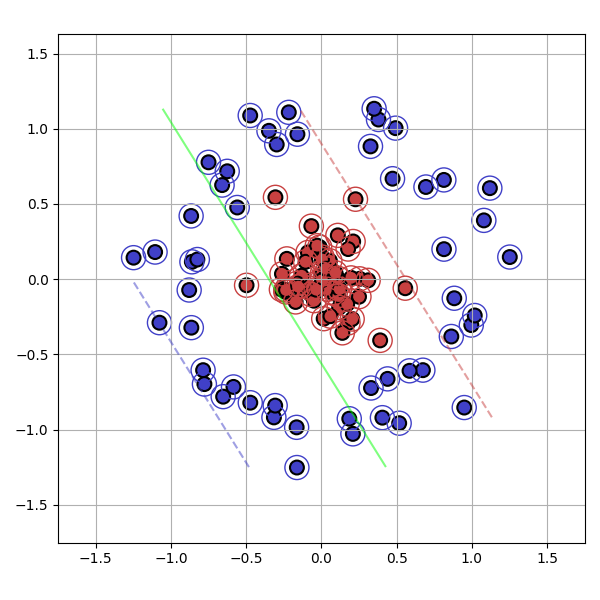

In [282]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, factor=.15, noise=.15, random_state=42)
xy_min, xy_max = X.min(axis=0), X.max(axis=0)

svc_model = SVC(kernel='linear').fit(X, y)

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap=m_cmap, edgecolors='black', linewidth=1.5)
plot_svc_decision_function(svc_model, ax, m_colors, y)
plt.grid()
lo = 0.5
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')

Очевидно, что эти данные не разделимы линейно. Спроецируем эти данные в пространство с большим числом измерений, где линейного разделителя будет достаточно. Например, одна из подходящих простых проекций &ndash; вычисление радиальной базисной функции (*RBF*), центрированной посередине совокупности данных:

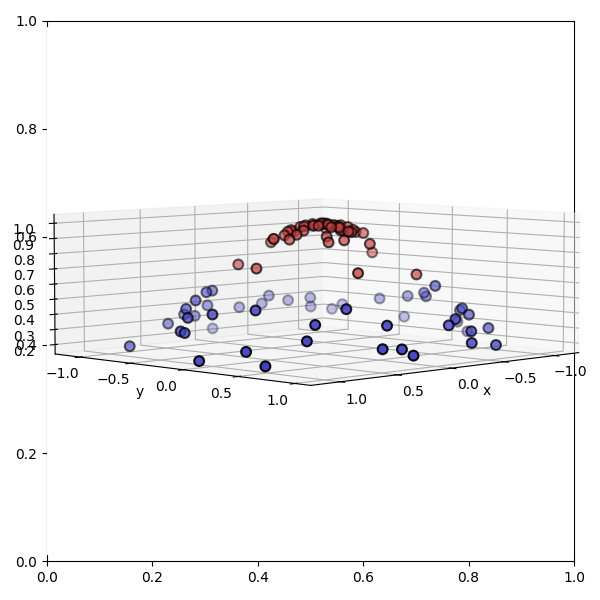

In [283]:
r = np.exp(-(X ** 2).sum(axis=1))

fig, ax = plt.subplots(figsize=(6, 6))
ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap=m_cmap, edgecolors='black', linewidth=1.5)
ax.view_init(elev=5, azim=45)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r')
plt.grid()
lo = 0.0
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')

In [284]:
from sklearn.svm import SVC
svc_model = SVC(kernel='rbf', C=1E10)
svc_model.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10000000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


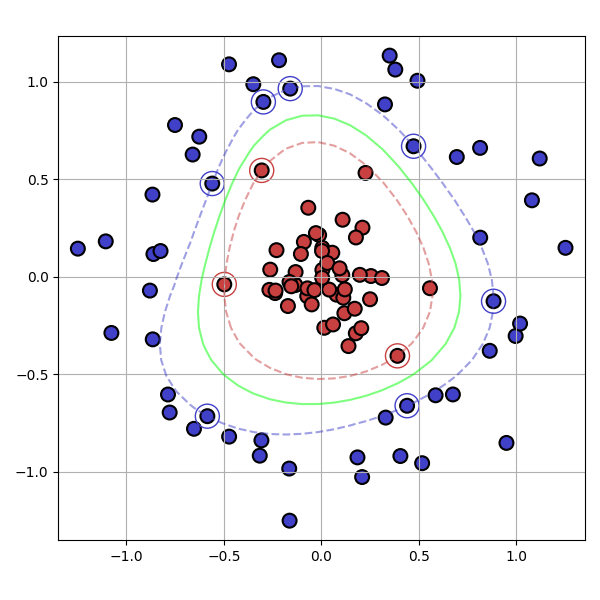

In [285]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=100,
            cmap=m_cmap, edgecolors='black', linewidth=1.5)
plot_svc_decision_function(svc_model, ax, m_colors, y)
plt.grid()
lo = 0.1
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
plt.tight_layout()
ax.set_aspect('equal', adjustable='box')

##### Пример 2

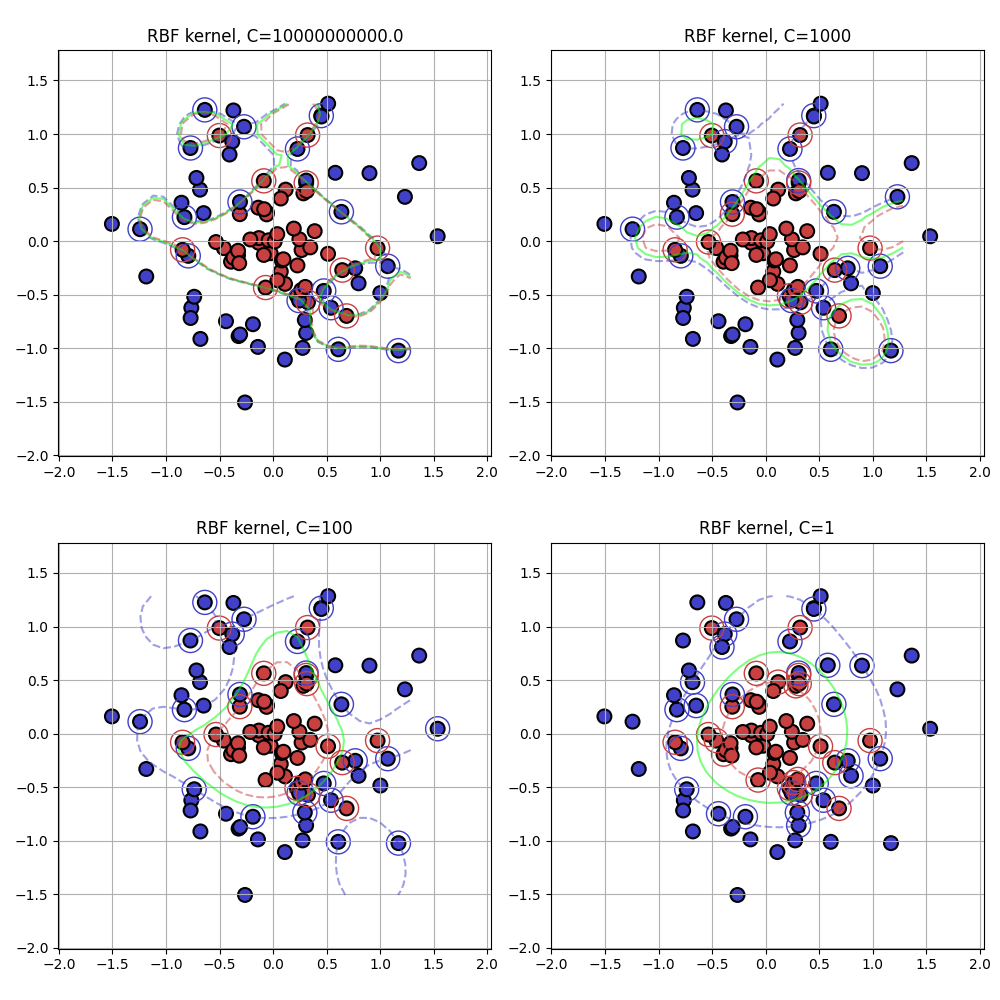

In [286]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, factor=.15, noise=.3, random_state=42)
xy_min, xy_max = X.min(axis=0), X.max(axis=0)

C_list = [1e10, 1000, 100, 1]

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for axi, c in zip(ax.flatten(), C_list):
    svc_model = SVC(kernel='rbf', C=c).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=100,
                cmap=m_cmap, edgecolors='black', linewidth=1.5)
    plot_svc_decision_function(svc_model, axi, m_colors, y)
    axi.grid()
    lo = 0.5
    axi.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
    axi.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
    axi.set_aspect('equal', adjustable='box')
    axi.set_title(f'RBF kernel, C={c}')
plt.tight_layout()


При очень большом значении параметра $C$ отступ задается «жестко» и точки не могут находиться на нем. При меньшем значении параметра $C$ отступ становится более размытым и может включать некоторые точки.  

Оптимальное значение параметра $C$ зависит от конкретного набора данных. Его следует настраивать с помощью перекрестной проверки или какой-либо аналогичной процедуры.

##### Пример 3

Источники:
- [Plot classification boundaries with different SVM Kernels @ sklearn](https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html)

Вспомогательная функция для построения решающей функции и областей:

In [287]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_svc_decision_function_area(model, ax, X, y, m_colors, plot_support_vectors=True):
    """Строит график решающей функции для двумерного SVC"""
    dl_colors = m_colors.copy()
    dl_colors.insert(len(dl_colors)//2, rgba2f(0, 255, 0))
    dl_cmap = mpl.colors.ListedColormap(dl_colors)
    m_cmap = mpl.colors.ListedColormap(m_colors)

    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, s=100,
               cmap=m_cmap, edgecolors='black', linewidth=1.5)
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")

    if plot_support_vectors:
        edge_colors = m_cmap(y[model.support_])
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=300, linewidth=1, edgecolors=edge_colors, facecolors='none')

    common_params = {"estimator": model, "X": X, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        cmap=dl_cmap,
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        cmap=dl_cmap,
        alpha=0.5
    )

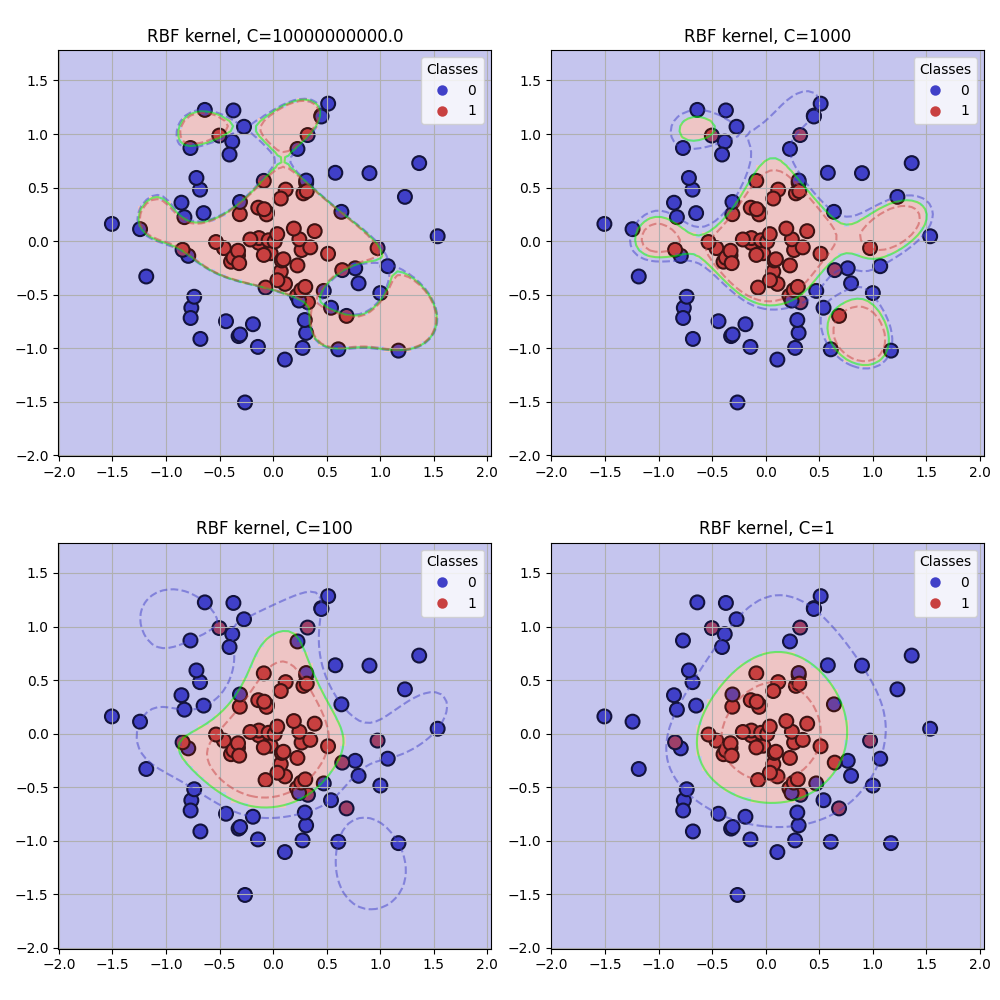

In [288]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for axi, c in zip(ax.flatten(), C_list):
    svc_model = SVC(kernel='rbf', C=c).fit(X, y)
    plot_svc_decision_function_area(svc_model, axi, X, y, m_colors, False)
    axi.grid()
    lo = 0.5
    axi.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
    axi.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
    axi.set_aspect('equal', adjustable='box')
    axi.set_title(f'RBF kernel, C={c}')
plt.tight_layout()

#### Достоинства и недостатки

Достоинства:
- Зависимость от относительно небольшого количества опорных векторов означает компактность модели и небольшой объем используемой оперативной памяти.
- Этап предсказания после обучения модели занимает очень мало времени.
- Поскольку на работу этих методов влияют только точки, находящиеся возле отступа, они хорошо подходят для многомерных данных &ndash; даже данных с количеством измерений, превышающим количество образцов, &ndash; непростые условия работы для других алгоритмов.
- Интеграция с ядерными методами делает их универсальными, обеспечивает приспособляемость к множеству типов данных.

Недостатки:
- Вычислительная сложность: при количестве образцов $N$ в наихудшем случае $O(N^3)$, $O(N^2)$ для более эффективных реализаций. При значительном количестве обучающих образцов вычислительные затраты могут оказаться непомерно высокими.
- Результаты зависят от удачности выбора параметра размытия $C$. Его необходимо тщательно выбирать с помощью перекрестной проверки, которая тоже может потребовать значительных вычислительных затрат при большом объеме данных.
- У результатов отсутствует непосредственная вероятностная интерпретация. Ее можно получить путем внутренней перекрестной проверки (см. параметр `probability` в классе `SVC`), но эта дополнительная оценка обходится недешево в смысле вычислительных затрат.

### 6.3 Метод главных компонент

Метод главных компонент (*principal component analysis*, *PCA*) &ndash; один из наиболее широко используемых алгоритмов машинного обучения без учителя. $PCA$ &ndash; это алгоритм понижения размерности, но его также можно применять как инструмент визуализации, фильтрации шума, выделения и проектирования признаков.

Источники:
- [Метод опорных векторов (SVM). Подходы, принцип работы и реализация с нуля на Python @ Хабр](https://habr.com/ru/articles/802185/)
- [Support Vector Machines @ sklearn](https://scikit-learn.org/stable/modules/svm.html)
- [SVC @ sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

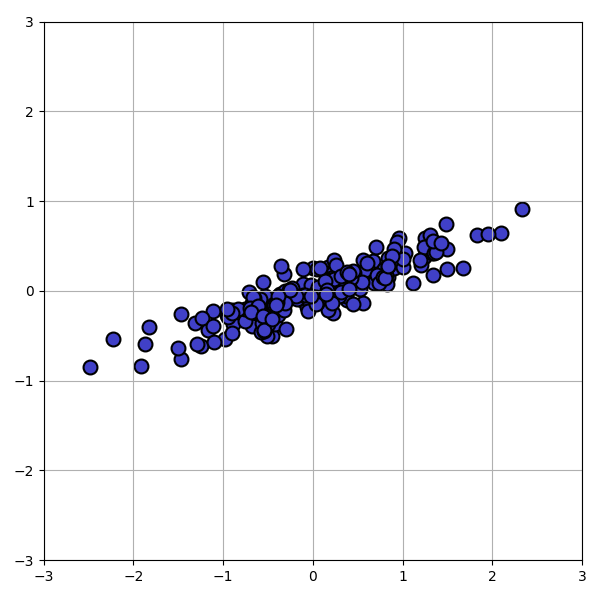

In [289]:
rng = np.random.RandomState(1)
X = np.dot(rng.rand(2, 2), rng.randn(2, 200)).T
xy_min, xy_max = X.min(axis=0), X.max(axis=0)
xy_min, xy_max = np.rint(xy_min), np.rint(xy_max)

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=100, color=m_colors[0],
            edgecolors='black', linewidth=1.5)
lo = 1.0
ax.grid()
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[0] - lo, xy_max[0] + lo])
# ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

Визуально очевидно, что зависимость между величинами $x$ и $y$ практически линейна. Это напоминает данные линейной регрессии, но постановка задачи здесь несколько иная: задача машинного обучения без учителя состоит в выяснении *зависимости между величинами $x$ и $y$*, а не в предсказании значений величины $y$ по значениям величины $x$.

В методе главных компонент выполняется количественная оценка этой зависимости путем поиска списка *главных осей координат* (*principal axes*) данных и их использования для описания набора данных.

In [290]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

При обучении алгоритм определяет некоторые относящиеся к данным величины, самые важные из них &ndash; компоненты и объясняемая ими дисперсия (*explained variance*):

In [291]:
pca.components_

array([[ 0.94446029,  0.32862557],
       [-0.32862557,  0.94446029]])

In [292]:
pca.explained_variance_

array([0.7625315, 0.0184779])

Чтобы понять смысл этих чисел, визуализируем их поверх исходных данных в виде векторов, направление которых определяется значениями главных компонент, а длина &ndash; объясняемой ими дисперсией:

In [293]:
def draw_vectors(pca_model, ax=None, s=3, color=None):
    ax = ax or plt.gca()
    arrowprops = dict(arrowstyle='->', linewidth=2, shrinkA=0, shrinkB=0, 
                      color=color)
    lom = 1.05
    for i, (length, vector) in enumerate(zip(pca_model.explained_variance_, pca_model.components_)):
        v = vector * 3 * np.sqrt(length)
        print(vector, v)
        v0 = pca_model.mean_
        v1 = pca_model.mean_ + v
        ax.annotate('', v1, v0, arrowprops=arrowprops)
        ax.text(v[0] * lom, v[1] * lom, f'pc{i + 1}')

[0.94446029 0.32862557] [2.47419458 0.86089761]
[-0.32862557  0.94446029] [-0.1340136   0.38515116]


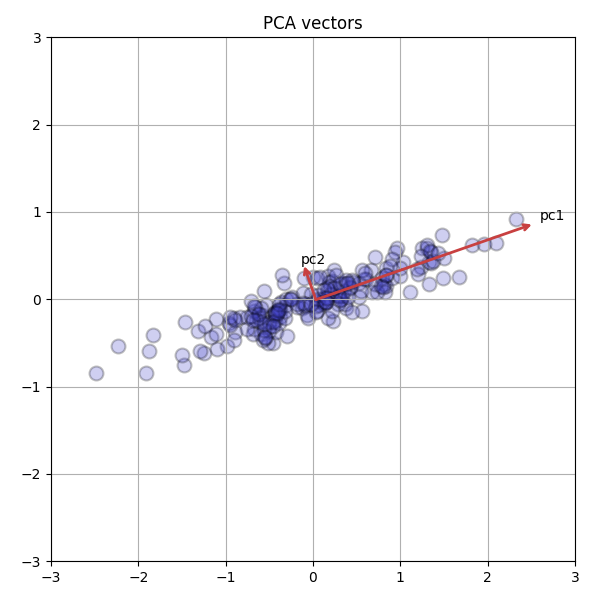

In [294]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=100, color=m_colors[0],
            edgecolors='black', linewidth=1.5, alpha=0.25)

draw_vectors(pca, ax=ax, color=m_colors[1])

lo = 1.0
ax.grid()
ax.set_xlim([xy_min[0] - lo, xy_max[0] + lo])
ax.set_ylim([xy_min[0] - lo, xy_max[0] + lo])
# ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
ax.set_title('PCA vectors')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()

Эти векторы представляют главные оси координат в пространстве данных, а их длины соответствуют «важности» осей для описания распределения данных, точнее, это мера дисперсии проекции данных на ось. Проекции точек данных на главные оси и есть главные компоненты.

Это преобразование, выполняющее переход от исходных осей координат к главным осям, &ndash; аффинное преобразование (*affine transformation*). В общем случае аффинное преобразование включает сдвиг (*translation*), поворот (*rotation*) и пропорциональное масштабирование (*uniform scaling*).

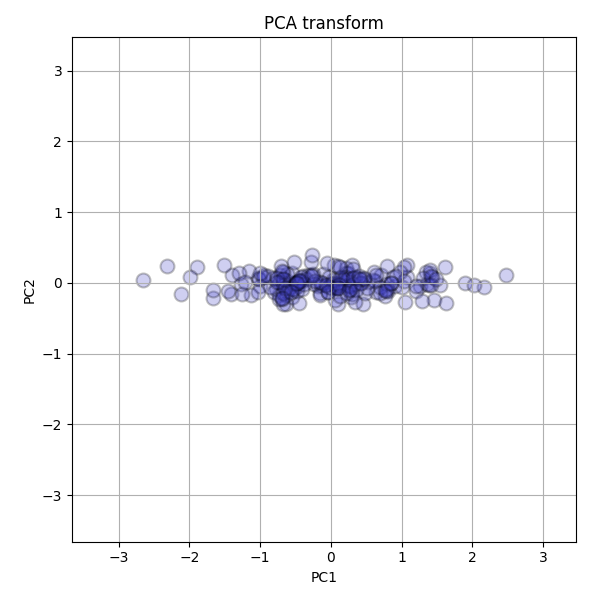

In [295]:
X_pca = pca.transform(X)
xy_pca_min, xy_pca_max = X_pca.min(axis=0), X_pca.max(axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=100, color=m_colors[0],
            edgecolors='black', linewidth=1.5, alpha=0.25)

lo = 1.0
ax.grid()
ax.set_xlim([xy_pca_min[0] - lo, xy_pca_max[0] + lo])
ax.set_ylim([xy_pca_min[0] - lo, xy_pca_max[0] + lo])
# ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
ax.set_aspect('equal', adjustable='box')
ax.set_title('PCA transform')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()

#### PCA как метод понижения размерности

Использование $PCA$ для понижения размерности включает обнуление одной или нескольких из минимальных главных компонент, в результате чего данные проецируются на пространство меньшей размерности с сохранением максимальной дисперсии данных.

In [296]:
pca = PCA(n_components=1)
pca.fit(X)
X_pca = pca.transform(X)
print("original shape: ", X.shape)
print("transformed shape:", X_pca.shape)

original shape:  (200, 2)
transformed shape: (200, 1)


В результате преобразования получились одномерные данные. Для лучшего понимания эффекта понижения размерности можно выполнить обратное преобразование данных и нарисовать их рядом с исходными.

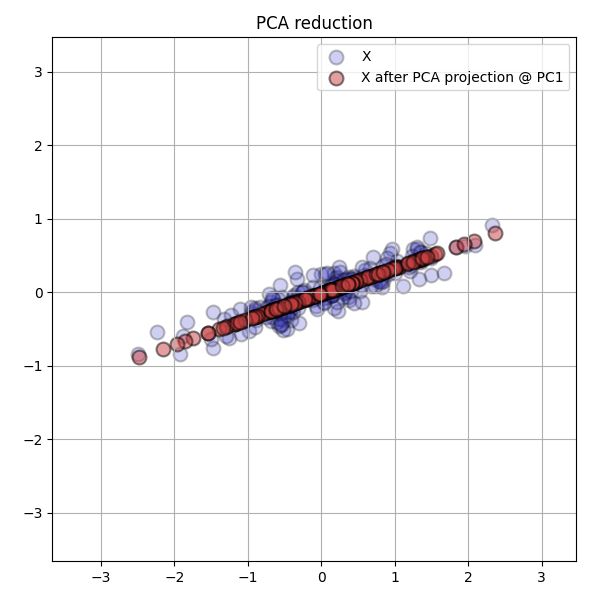

In [297]:
X_pca_inv = pca.inverse_transform(X_pca)

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=100, color=m_colors[0],
            edgecolors='black', linewidth=1.5, alpha=0.25)
plt.scatter(X_pca_inv[:, 0], X_pca_inv[:, 1], s=100, color=m_colors[1],
            edgecolors='black', linewidth=1.5, alpha=0.5)

lo = 1.0
ax.grid()
ax.set_xlim([xy_pca_min[0] - lo, xy_pca_max[0] + lo])
ax.set_ylim([xy_pca_min[0] - lo, xy_pca_max[0] + lo])
# ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
ax.set_aspect('equal', adjustable='box')
ax.set_title('PCA reduction')
ax.legend(['X', 'X after PCA projection @ PC1'])
plt.tight_layout()

Этот рисунок наглядно показывает, как происходит понижение размерности с помощью $PCA$: информация по наименее важным главным осям координат уничтожается, и остаются только компоненты данных с максимальной дисперсией. Отсекаемая часть дисперсии (пропорциональная разбросу точек рядом с линией, на рисунке) является приближенной мерой объема «информации», отбрасываемого при понижении размерности.

##### Пример

Датасет `load_digits`.

In [298]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [299]:
digits.data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

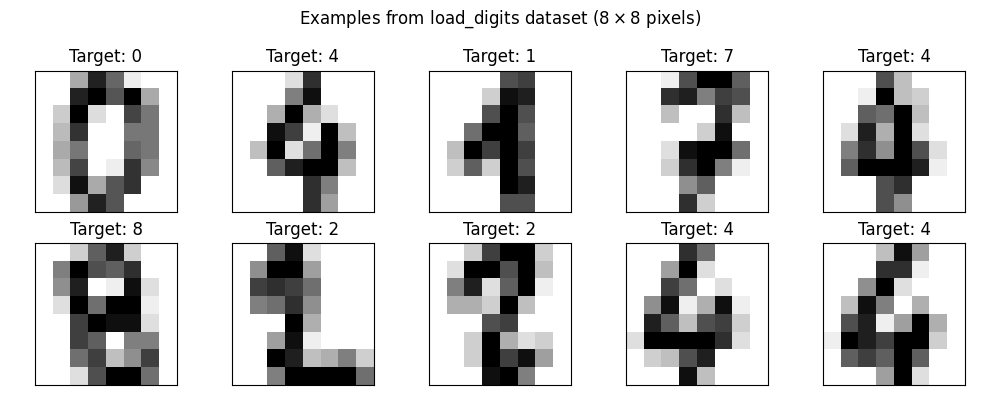

In [300]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i, axi in enumerate(ax.flatten()):
    axi.imshow(digits.images[0 + 100 * i], cmap=plt.cm.gray_r, interpolation='nearest')
    axi.set_title(f"Target: {digits.target[0 + 100 * i]}")
    axi.set_aspect('equal', adjustable='box')
    axi.set_xticks([])
    axi.set_yticks([])
fig.suptitle('Examples from load_digits dataset ($8 \\times 8$ pixels)')
plt.tight_layout()

In [301]:
digits.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Каждый сэмпл данных представляет собой 64-мерный вектор. Чтобы понять зависимости между этими точками, воспользуемся методом $PCA$ и спроецируем их в пространство меньшей размерности, например двумерное:

In [302]:
pca = PCA(2) # Проекция 64-мерного пространства в 2-мерное
projected = pca.fit_transform(digits.data)
print(digits.data.shape)
print(projected.shape)

(1797, 64)
(1797, 2)


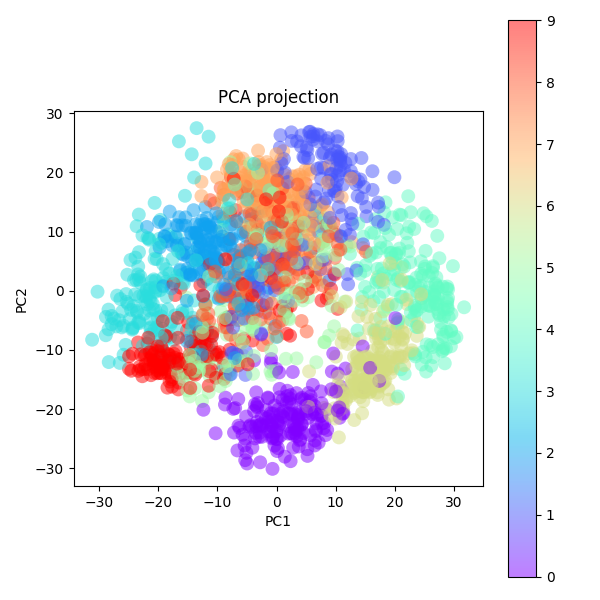

In [303]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(projected[:, 0], projected[:, 1], s=100, c=digits.target,
            edgecolors='none', linewidth=1.5, alpha=0.5,
            cmap=plt.colormaps['rainbow'])

# lo = 1.0
# ax.grid()
# ax.set_xlim([xy_pca_min[0] - lo, xy_pca_max[0] + lo])
# ax.set_ylim([xy_pca_min[0] - lo, xy_pca_max[0] + lo])
# ax.set_ylim([xy_min[1] - lo, xy_max[1] + lo])
ax.set_aspect('equal', adjustable='box')
ax.set_title('PCA projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar()
plt.tight_layout()


Каждое изображение из обучающей последовательности описывается набором 64 значений пикселов:

$$
x = \left[ x_1, x_2, x_3, \dots x_{63}, x_{64} \right]
$$

Мы можем рассматривать это в терминах *пиксельного* базиса, то есть для формирования изображения необходимо умножить каждый элемент вышеприведенного вектора на значение описываемого им пиксела, после чего сложить результаты:

$$
image(x) = x_1 \cdot \text{пиксел 1} + x_2 \cdot \text{пиксел 2} + x_3 \cdot \text{пиксел 3} + \dots + x_{64} \cdot \text{пиксел 64}
$$

Один из возможных способов понижения размерности этих данных &ndash; обнуление большей части базисных векторов. Например, если использовать только первые восемь пикселов, то получится восьмимерная проекция данных, но она будет плохо отражать изображения в целом, потому что отбрасывается почти $90\%$ пикселов.  

Метод $PCA$ можно рассматривать как процесс выбора оптимальных базисных функций, чтобы комбинации лишь нескольких из них было достаточно для удовлетворительного воссоздания основной части элементов набора данных.  

Важнейшая составная часть применения метода $PCA$ на практике &ndash; оценка количества компонент, необходимого для описания данных. Определить это количество можно с помощью представления *интегральной доли объясняемой дисперсии* (*explained variance ratio*) в виде функции от количества компонент:

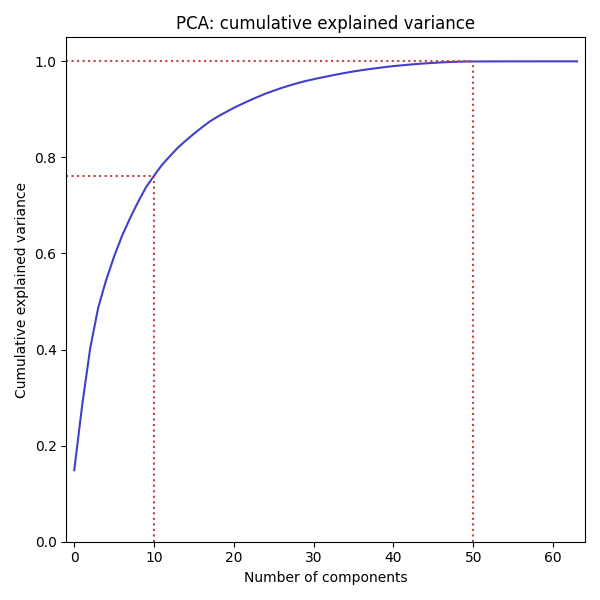

In [304]:
pca = PCA().fit(digits.data)

fig, ax = plt.subplots(figsize=(6, 6))

data = np.cumsum(pca.explained_variance_ratio_)

ax.plot(data, color=m_colors[0], linewidth=1.5)
ax.vlines(x=10, color=m_colors[1], linestyle=':', ymin=0.0, ymax=data[10], linewidth=1.5)
ax.hlines(y=data[10], color=m_colors[1], linestyle=':', xmin=-1, xmax=10, linewidth=1.5)

ax.vlines(x=50, color=m_colors[1], linestyle=':', ymin=0.0, ymax=data[50], linewidth=1.5)
ax.hlines(y=data[50], color=m_colors[1], linestyle=':', xmin=-1, xmax=50, linewidth=1.5)

# ax.set_aspect('equal', adjustable='box')
ax.set_title('PCA: cumulative explained variance')
ax.set_xlim([-1, 64])
ax.set_ylim([0, 1.05])
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
plt.tight_layout()

Эта кривая представляет количественную оценку содержания общей, 64-мерной, дисперсии в первых $N$ компонентах. Например, на рисунке видно, что первые $10$ компонент набора данных с изображениями рукописных цифр описывают примерно $75\%$ дисперсии, а для описания доли дисперсии, близкой к $100\%$, необходимо около $50$ компонент.

В данном случае мы видим, что *двумерная проекция* теряет массу информации (согласно оценке объясняемой дисперсии) и что для сохранения $90\%$ дисперсии необходимо около $20$ компонент. Подобный график для многомерного набора данных помогает оценить уровень избыточности, присутствующей в признаках.

#### Принцип работы PCA

Изначально матрица признаков обязательно центрируется, чтобы первая главная компонента могла соответствовать направлению максимальной вариации данных, а не просто их среднему значению. Обычно нахождение главных компонент сводится к двум основным методам:
- Вычисление собственных векторов и собственных значений ковариационной матрицы данных.  
  Поскольку ковариационная матрица отражает степень линейной связи между различными переменными, то собственные вектора этой матрицы будут задавать направления, вдоль которых дисперсия данных максимальна, а собственные значения &ndash; величину этой дисперсии. Собственное значение, соответствующее собственному вектору, характеризует вклад этого вектора в объяснение дисперсии данных и чем больше собственное значение, тем значимее главная компонента. Обычно отбираются только те главные компоненты, которые объясняют заданный уровень дисперсии, например, $95\%$.
- Вычисление сингулярного разложения матрицы данных.  
  Сингулярное разложение &ndash; это способ представления любой матрицы в виде произведения трёх матриц:
  + левой сингулярной матрицы $U$,
  + диагональной матрицы сингулярных значений $S$,
  + правой сингулярной матрицы $V$,  

  где сингулярные значения &ndash; это квадратные корни собственных значений ковариационной матрицы данных (именно для этого в данном случае выполняется предварительное центрирование данных). Правая сингулярная матрица $V$ будет соответствовать собственным векторам ковариационной матрицы данных, а левая $U$ будет являться проекцией исходных данных на главные компоненты, определённые матрицей $V$. Таким образом, сингулярное разложение также позволяет выделить главные компоненты, но без необходимости в вычислении ковариационной матрицы. Помимо того, что такое решение более эффективно, оно считается более численно стабильным, поскольку не требует вычисления ковариационной матрицы напрямую, которая может быть плохо обусловлена в случае сильной корреляции признаков. Именно данный подход используется в реализации `scikit-learn`, но с некоторыми особенностями, рассмотренными ниже.

#### Дополнительные возможности PCA

- Коэффициент объяснённой дисперсии каждой главной компоненты, доступный через переменную `explained_variance_ratio_`, указывает долю дисперсии датасета, лежащей вдоль оси каждой главной компоненты.
- Восстановление данных с помощью метода `inverse_transform()` заключается в применении обратной трансформации проекции $PCA$ вида $X_{recovered} = X_{d-proj} W_d^T$, где $W_d^T$ &ndash; матрица из первых $d$ главных компонент. Из этого следует, что данные будут восстановлены с потерями, пропорциональными количеству отброшенной дисперсии исходных данных, а средний квадрат расстояния между исходными и восстановленными данными представляет собой ошибку восстановления (*reconstruction error*).
- Инкрементный PCA, реализованный в виде класса [IncrementalPCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.IncrementalPCA), позволяет работать эффективнее с большими наборами данных за счёт их разбиения на мини-пакеты и поштучном хранении в памяти во время обучения.
- Рандомизированный PCA, устанавливаемый с помощью параметра `svd_solver='randomized'`, использует стохастический алгоритм для быстрого вычисления приближённых $d$ главных компонент и основан на предположении, что случайная проекция данных на низкоразмерное подпространство может хорошо сохранять их структуру и свойства, однако такой подход может быть менее точным.
- Ядерный PCA, реализованный с помощью класса [KernelPCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html), позволяет выполнять сложные нелинейные проекции с использованием ядерных функций. Как и в случае с $SVM$, его суть в данном случае заключается в том, что линейная граница решений в многомерном пространстве признаков будет соответствовать сложной нелинейной границе в исходном пространстве.

#### Альтернативы PCA

Несмотря на то, что метод главных компонент является одним из самых популярных алгоритмов понижения размерности, существуют альтернативы, которые могут быть более предпочтительными в ряде ситуаций, а также в зависимости от типа данных:
- $LLE$ (*Locally Linear Embedding*) &ndash; алгоритм создания линейных комбинаций каждой точки из её соседей с последующим восстановлением этих комбинаций в пространстве более низкой размерности, что позволяет сохранить нелинейную геометрию данных и быть полезным для некоторых задач, где глобальные свойства менее важны. С другой стороны, такой подход имеет высокую вычислительную сложность и может быть чувствителен к шуму.
- $\textit{t-SNE}$ (*t-Distributed Stochastic Neighbor Embedding*) &ndash; алгоритм, который преобразует сходства между данными в вероятности и в дальнейшем пытается минимизировать расхождение между распределениями вероятностей в пространстве высокой и низкой размерности. $\textit{t-SNE}$ эффективен при визуализации данных высокой размерности, однако может искажать глобальную структуру данных, поскольку не учитывает линейные зависимости, а лишь их близость в исходном пространстве.
- $UMAP$ (*Uniform Manifold Approximation and Projection*) &ndash; ещё один алгоритм, подходящий для визуализации данных, который основан на идеи, что данные лежат на некотором однородном многообразии, которое можно аппроксимировать с помощью графа соседей. Такой подход учитывает глобальную структуру данных и позволяет лучше адаптироваться к различным типам данных, а также лучше справляться с шумом и выбросами, чем $\textit{t-SNE}$.
- $\textit{Autoencoders}$ &ndash; тип нейронных сетей, основанный на обучении кодировщика преобразовывать входные данные в низкоразмерное представление, с последующим обучением декодера восстанавливать исходные данные из этого представления. $\textit{Autoencoders}$ могут также использоваться для сжатия данных, удаления шума и многих других целей.

Основной недостаток метода PCA состоит в том, что сильное влияние на него оказывают аномальные значения в данных. Поэтому было разработано немало вариантов PCA, устойчивых к ошибкам, многие из которых стремятся итеративно отбрасывать те точки данных, которые описываются исходными компонентами недостаточно хорошо. Библиотека `scikit-learn` содержит несколько реализаций интересных вариантов метода PCA в модуле `sklearn.decomposition`, включая класс `SparsePCA`, который вводит понятие регуляризации, для обеспечения разреженности компонент.